# Online Customer Segmentation Project

## Project Overview

This project analyzes one year of transaction data from a UK-based online retailer, specializing in gifts and home decor.
The data was cleaned using SQL, applied RFM modeling + KMeans clustering in R, and built Tableau dashboards to reveal customer insights.

## Importing Necessary Modules

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler    


### Data Preview

In [2]:

# Read CSV files using relative paths
customer_summary_df = pd.read_csv('customer_summary copy.csv')
monthly_sales_df = pd.read_csv('monthly_sales copy.csv')
retail_cleaned_df = pd.read_csv('retail_cleaned.csv')
retail_segmented_df = pd.read_csv('retail_segmented.csv')

C:\Users\HomePC\AppData\Local\Temp\ipykernel_21960\2425743287.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  retail_cleaned_df = pd.read_csv('retail_cleaned.csv')


In [3]:
customer_summary_df.head(10)

,CustomerID,total_orders,total_quantity,total_spent,last_purchase,first_purchase
0,12346.0,1,74215,77183.60,2011-1-18 10:01:00,2011-1-18 10:01:00
1,12347.0,7,2458,4310.00,2011-12-7 15:52:00,2010-12-7 14:57:00
2,12348.0,4,2341,1797.24,2011-9-25 13:13:00,2010-12-16 19:09:00
3,12349.0,1,631,1757.55,2011-11-21 09:51:00,2011-11-21 09:51:00
4,12350.0,1,197,334.40,2011-2-2 16:01:00,2011-2-2 16:01:00
5,12352.0,8,536,2506.04,2011-11-3 14:37:00,2011-2-16 12:33:00
6,12353.0,1,20,89.00,2011-5-19 17:47:00,2011-5-19 17:47:00
7,12354.0,1,530,1079.40,2011-4-21 13:11:00,2011-4-21 13:11:00
8,12355.0,1,240,459.40,2011-5-9 13:49:00,2011-5-9 13:49:00
9,12356.0,3,1591,2811.43,2011-11-17 08:40:00,2011-1-18 09:50:00


In [4]:
monthly_sales_df.head(10)

,InvoiceMonth,monthly_revenue
0,1/12/2010,823746.14
1,1/1/2011,691364.56
2,1/2/2011,523631.89
3,1/3/2011,717639.36
4,1/4/2011,537808.62
5,1/5/2011,770536.02
6,1/6/2011,761739.90
7,1/7/2011,719221.19
8,1/8/2011,759138.38
9,1/9/2011,1058590.17


In [5]:
retail_cleaned_df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-1 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-1 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-1 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-1 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-1 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-1
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-1 08:26:00,7.65,17850.0,United Kingdom,15.30,2010-12-1
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-1 08:26:00,4.25,17850.0,United Kingdom,25.50,2010-12-1
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-1 08:28:00,1.85,17850.0,United Kingdom,11.10,2010-12-1
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-1 08:28:00,1.85,17850.0,United Kingdom,11.10,2010-12-1
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-1 08:34:00,1.69,13047.0,United Kingdom,54.08,2010-12-1


In [6]:
retail_segmented_df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth,Segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-1 08:26:00,2.55,17850,United Kingdom,15.30,2010-12-1,2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-1 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-1,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-1 08:26:00,2.75,17850,United Kingdom,22.00,2010-12-1,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-1 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-1,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-1 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-1,2
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-1 08:26:00,7.65,17850,United Kingdom,15.30,2010-12-1,2
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-1 08:26:00,4.25,17850,United Kingdom,25.50,2010-12-1,2
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-1 08:28:00,1.85,17850,United Kingdom,11.10,2010-12-1,2
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-1 08:28:00,1.85,17850,United Kingdom,11.10,2010-12-1,2
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-1 08:34:00,1.69,13047,United Kingdom,54.08,2010-12-1,4


In [7]:
customer_summary_df.dtypes


CustomerID        float64
total_orders        int64
total_quantity      int64
total_spent       float64
last_purchase      object
first_purchase     object
dtype: object

In [8]:
monthly_sales_df.dtypes

InvoiceMonth        object
monthly_revenue    float64
dtype: object

In [9]:
retail_cleaned_df.dtypes

InvoiceNo        object
StockCode        object
Description      object
Quantity          int64
InvoiceDate      object
UnitPrice       float64
CustomerID      float64
Country          object
TotalPrice      float64
InvoiceMonth     object
dtype: object

In [10]:
retail_segmented_df.dtypes


InvoiceNo         int64
StockCode        object
Description      object
Quantity          int64
InvoiceDate      object
UnitPrice       float64
CustomerID        int64
Country          object
TotalPrice      float64
InvoiceMonth     object
Segment           int64
dtype: object

In [11]:
# Check for missing values in each DataFrame
print("Missing values in customer_summary_df:")
print(customer_summary_df.isnull().sum())
print("\nMissing values in monthly_sales_df:")
print(monthly_sales_df.isnull().sum())
print("\nMissing values in retail_cleaned_df:")
print(retail_cleaned_df.isnull().sum())
print("\nMissing values in retail_segmented_df:")
print(retail_segmented_df.isnull().sum())


Missing values in customer_summary_df:
CustomerID        1
total_orders      0
total_quantity    0
total_spent       0
last_purchase     0
first_purchase    0
dtype: int64

Missing values in monthly_sales_df:
InvoiceMonth       0
monthly_revenue    0
dtype: int64

Missing values in retail_cleaned_df:
InvoiceNo            0
StockCode            0
Description          0
Quantity             0
InvoiceDate          0
UnitPrice            0
CustomerID      132220
Country              0
TotalPrice           0
InvoiceMonth         0
dtype: int64

Missing values in retail_segmented_df:
InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID      0
Country         0
TotalPrice      0
InvoiceMonth    0
Segment         0
dtype: int64


In [12]:
# Remove rows with missing values in retail_cleaned_df
retail_cleaned_df = retail_cleaned_df.dropna()


In [13]:
# Remove rows with negative quantity or price in retail_cleaned_df
retail_cleaned_df = retail_cleaned_df[(retail_cleaned_df['Quantity'] > 0) & (retail_cleaned_df['TotalPrice'] > 0)]


In [14]:
## Remove rows with missing CustomerID in retail_segmented_df
retail_segmented_df = retail_segmented_df.dropna(subset=['CustomerID'])

In [15]:
retail_segmented_df.shape

(397884, 11)

In [38]:
### Fixing InvoiceDate format in retail_cleaned_df
retail_cleaned_df['InvoiceDate'] = pd.to_datetime(retail_cleaned_df['InvoiceDate'], dayfirst=False, errors='coerce')
retail_cleaned_df['InvoiceMonth'] = retail_cleaned_df['InvoiceDate'].dt.strftime('%Y-%m')
print(retail_cleaned_df[['InvoiceDate', 'InvoiceMonth']].head(5))


          InvoiceDate InvoiceMonth
0 2010-12-01 08:26:00      2010-12
1 2010-12-01 08:26:00      2010-12
2 2010-12-01 08:26:00      2010-12
3 2010-12-01 08:26:00      2010-12
4 2010-12-01 08:26:00      2010-12


### Exploratory Data Analysis

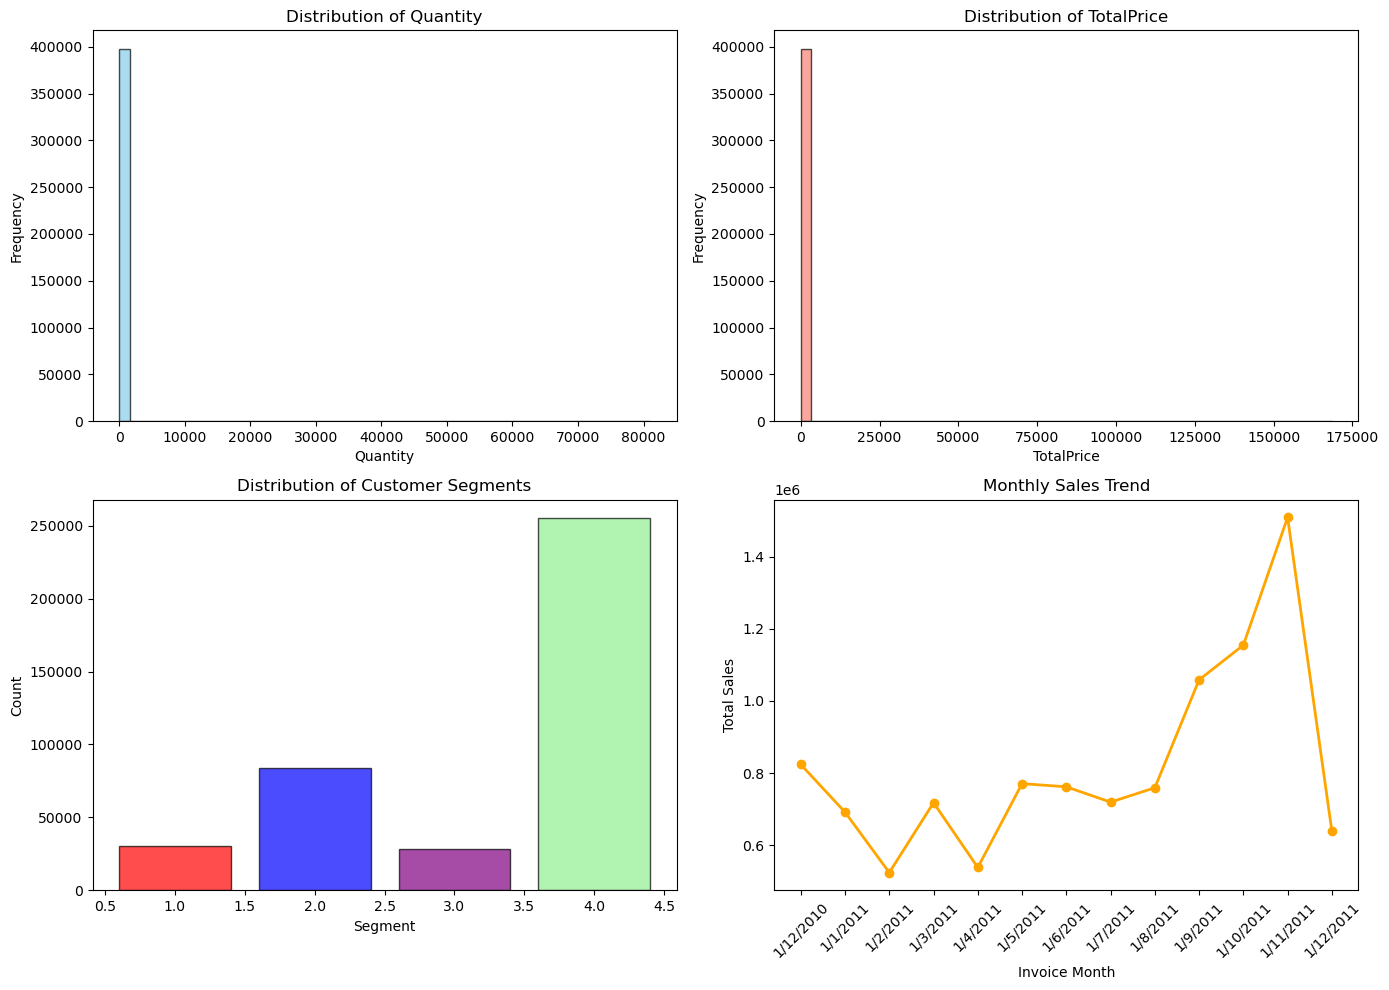

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Quantity Distribution
axes[0, 0].hist(retail_cleaned_df['Quantity'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Quantity')
axes[0, 0].set_xlabel('Quantity')
axes[0, 0].set_ylabel('Frequency')

# TotalPrice Distribution
axes[0, 1].hist(retail_cleaned_df['TotalPrice'], bins=50, color='salmon', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of TotalPrice')
axes[0, 1].set_xlabel('TotalPrice')
axes[0, 1].set_ylabel('Frequency')

# Customer Segments Distribution
axes[1, 0].bar(retail_segmented_df['Segment'].value_counts().index, retail_segmented_df['Segment'].value_counts().values, color=['lightgreen','blue','red','purple'], edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribution of Customer Segments')
axes[1, 0].set_xlabel('Segment')
axes[1, 0].set_ylabel('Count')

# Monthly Sales Trend
axes[1, 1].plot(monthly_sales_df['InvoiceMonth'], monthly_sales_df['monthly_revenue'], marker='o', color='orange', linewidth=2)
axes[1, 1].set_title('Monthly Sales Trend') 
axes[1, 1].set_xlabel('Invoice Month')
axes[1, 1].set_ylabel('Total Sales')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### SQL Connections and Queries


In [42]:
conn=sqlite3.connect('customer_segmentation.db')

# Remove duplicate columns before writing to SQL
retail_cleaned_df = retail_cleaned_df.loc[:, ~retail_cleaned_df.columns.duplicated()]
retail_cleaned_df.to_sql('retail_cleaned', conn, if_exists='replace', index=False)
retail_segmented_df.to_sql('retail_segmented', conn, if_exists='replace', index=False)
customer_summary_df.to_sql('customer_summary', conn, if_exists='replace', index=False)
monthly_sales_df.to_sql('monthly_sales', conn, if_exists='replace', index=False)


13

In [43]:
retail_cleaned_check = pd.read_sql_query("""
    SELECT 
        InvoiceNo,
        Quantity,
        UnitPrice,
        ROUND(Quantity * UnitPrice, 2) AS TotalPrice_check,
        InvoiceMonth                   AS InvoiceMonth_check
    FROM retail_cleaned
    WHERE Quantity   > 0
      AND UnitPrice  > 0
      AND CustomerID IS NOT NULL
    LIMIT 10
""", conn)

print(retail_cleaned_check)

  InvoiceNo  Quantity  UnitPrice  TotalPrice_check InvoiceMonth_check
0    536365         6       2.55             15.30            2010-12
1    536365         6       3.39             20.34            2010-12
2    536365         8       2.75             22.00            2010-12
3    536365         6       3.39             20.34            2010-12
4    536365         6       3.39             20.34            2010-12
5    536365         2       7.65             15.30            2010-12
6    536365         6       4.25             25.50            2010-12
7    536366         6       1.85             11.10            2010-12
8    536366         6       1.85             11.10            2010-12
9    536367        32       1.69             54.08            2010-12


In [44]:
monthly_sales_df = pd.read_sql_query("""
                                     SELECT InvoiceMonth,
                                     ROUND(SUM(TotalPrice), 2) AS monthly_revenue
                                      FROM retail_cleaned
                                     GROUP BY InvoiceMonth
                                     ORDER BY InvoiceMonth
                                     """, conn)
print(monthly_sales_df.head(10))

  InvoiceMonth  monthly_revenue
0      2010-12        572713.89
1      2011-01        569445.04
2      2011-02        447137.35
3      2011-03        595500.76
4      2011-04        469200.36
5      2011-05        678594.56
6      2011-06        661213.69
7      2011-07        600091.01
8      2011-08        645343.90
9      2011-09        952838.38


In [48]:
customer_summary_df = pd.read_sql_query("""
                                        SELECT CustomerID,
                                        COUNT(DISTINCT InvoiceNo) AS total_orders,
                                        ROUND(SUM(TotalPrice), 2) AS total_spent,
                                        MAX(DATE(InvoiceDate)) AS last_purchase_date,
                                        MIN(DATE(InvoiceDate)) AS first_purchase_date
                                        FROM retail_cleaned
                                        GROUP BY CustomerID
                                        """, conn)
print(customer_summary_df.head(10))
print(customer_summary_df.dtypes)


   CustomerID  total_orders  total_spent last_purchase_date  \
0     12346.0             1     77183.60         2011-01-18   
1     12347.0             7      4310.00         2011-12-07   
2     12348.0             4      1797.24         2011-09-25   
3     12349.0             1      1757.55         2011-11-21   
4     12350.0             1       334.40         2011-02-02   
5     12352.0             8      2506.04         2011-11-03   
6     12353.0             1        89.00         2011-05-19   
7     12354.0             1      1079.40         2011-04-21   
8     12355.0             1       459.40         2011-05-09   
9     12356.0             3      2811.43         2011-11-17   

  first_purchase_date  
0          2011-01-18  
1          2010-12-07  
2          2010-12-16  
3          2011-11-21  
4          2011-02-02  
5          2011-02-16  
6          2011-05-19  
7          2011-04-21  
8          2011-05-09  
9          2011-01-18  
CustomerID             float64
total_order

### Computing RFM Values (Recency, Frequency and Monetary Values)

The RFM values are used to show how recent a customer made a purchase, the number of times the customer made a purchase and the amount of money a customer spent. These values show who the real and the best customers are. Also, these values will then be used for KMeans clustering since it requires numerical input values that genuinely seperate customers into distinct behavioural groups.

In [49]:
retail_cleaned_df['InvoiceDate'] = pd.to_datetime(retail_cleaned_df['InvoiceDate'])
reference_date = retail_cleaned_df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = retail_cleaned_df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)
print(rfm.head(10))
print(rfm.describe())


C:\Users\HomePC\AppData\Local\Temp\ipykernel_21960\133677873.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  retail_cleaned_df['InvoiceDate'] = pd.to_datetime(retail_cleaned_df['InvoiceDate'])


   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40
5     12352.0       36          8   2506.04
6     12353.0      204          1     89.00
7     12354.0      232          1   1079.40
8     12355.0      214          1    459.40
9     12356.0       23          3   2811.43
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266459
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.00

In [50]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print("Scaled Shape:", rfm_scaled.shape)
print("First 5 rows:\n", rfm_scaled[:5])


Scaled Shape: (4338, 3)
First 5 rows:
 [[ 2.33457414 -0.4250965   8.35866818]
 [-0.90534032  0.3544168   0.25096626]
 [-0.17535959 -0.03533985 -0.02859601]
 [-0.73534481 -0.4250965  -0.0330118 ]
 [ 2.17457836 -0.4250965  -0.19134727]]


#### Applying KMeans Clustering


In [52]:
kmeans = KMeans(n_clusters=4, n_init=25, max_iter=300, random_state=42)
kmeans.fit(rfm_scaled)

print("Cluster Sizes:\n", pd.Series(kmeans.labels_).value_counts().sort_index())
print("\nCluster Centers:\n", pd.DataFrame(kmeans.cluster_centers_, columns=['Recency', 'Frequency', 'Monetary']).round(3))



Cluster Sizes:
 0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

Cluster Centers:
    Recency  Frequency  Monetary
0   -0.488     -0.077    -0.077
1    1.555     -0.353    -0.175
2   -0.851     10.168    13.939
3   -0.770      2.347     1.185


#### Merge Cluster labels back to RFM table

In [64]:
rfm['Cluster'] = kmeans.labels_

segment_map = {
    0: 'Casual Customers',
    1: 'Lost Customers',
    2: 'Champions',
    3: 'Loyal Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

In [65]:
print (rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']].head(10))
print("\nSegment counts:\n", rfm['Segment'].value_counts())


   CustomerID  Recency  Frequency  Monetary  Cluster           Segment
0     12346.0      326          1  77183.60        3   Loyal Customers
1     12347.0        2          7   4310.00        0  Casual Customers
2     12348.0       75          4   1797.24        0  Casual Customers
3     12349.0       19          1   1757.55        0  Casual Customers
4     12350.0      310          1    334.40        1    Lost Customers
5     12352.0       36          8   2506.04        0  Casual Customers
6     12353.0      204          1     89.00        1    Lost Customers
7     12354.0      232          1   1079.40        1    Lost Customers
8     12355.0      214          1    459.40        1    Lost Customers
9     12356.0       23          3   2811.43        0  Casual Customers

Segment counts:
 Segment
Casual Customers    3054
Lost Customers      1067
Loyal Customers      204
Champions             13
Name: count, dtype: int64


#### Merge back to retail_cleaned_df

In [67]:
retail_segmented_df = retail_cleaned_df.merge(rfm[['CustomerID', 'Segment']], on='CustomerID', how='left')

print (retail_segmented_df.shape)
print(retail_segmented_df[['CustomerID', 'Segment']].drop_duplicates().head(10))


(397880, 13)
     CustomerID           Segment
0       17850.0   Loyal Customers
9       13047.0  Casual Customers
26      12583.0   Loyal Customers
46      13748.0  Casual Customers
65      15100.0    Lost Customers
82      15291.0   Loyal Customers
86      14688.0   Loyal Customers
105     17809.0  Casual Customers
106     15311.0         Champions
141     16098.0  Casual Customers


In [68]:
# Verifying no customers were lost during the merge
print("Rows before merge:", retail_cleaned_df.shape[0])
print("Rows after merge:", retail_segmented_df.shape[0])
print("Null Segments:", retail_segmented_df['Segment'].isnull().sum())


Rows before merge: 397880
Rows after merge: 397880
Null Segments: 0


In [69]:
rfm. to_csv('rfm_segments.csv', index=False)
retail_segmented_df.to_csv('retail_segmented.csv', index=False)

print("Export Complete!!!")
print(retail_segmented_df[['InvoiceNo', 'CustomerID', 'TotalPrice', 'Segment']].head(10))

Export Complete!!!
  InvoiceNo  CustomerID  TotalPrice           Segment
0    536365     17850.0       15.30   Loyal Customers
1    536365     17850.0       20.34   Loyal Customers
2    536365     17850.0       22.00   Loyal Customers
3    536365     17850.0       20.34   Loyal Customers
4    536365     17850.0       20.34   Loyal Customers
5    536365     17850.0       15.30   Loyal Customers
6    536365     17850.0       25.50   Loyal Customers
7    536366     17850.0       11.10   Loyal Customers
8    536366     17850.0       11.10   Loyal Customers
9    536367     13047.0       54.08  Casual Customers


## Conclusion

From the RFM segmentation above, it is revealed that there are 4 distinct groups from a total of 4338 customers. Here is what each segment means given the context above:

    1. Champions (13 Customers -~0.3% customer base) - These are most certainly wholesale or trade buyers. The extraordinarily high frequency (z-score of +10), and monetary value (z-score of +13) means they are not typical retail shoppers but repeat bulk purchasers. Despite being just 13 customers, they most likely drive a signigicant potion of total revenue.

    2. Loyal Customers (204 Customers -~4.7% customer base) - These are recent buyers with above-average frequency and spend. These are engaged retail customers who have demonstrated a genuine habit of returning to the store.

    3. Casual Customers (3054 Customers -~70.4% customer base) - This is the largest segment by far. Average recency, frequency and spend. These customers who buy occasionally but have not developed a strong habit or loyalty. Many are likely one-time or infrequent gift buyers.

    4. Lost Customers (1067 Customers -~24.6% customer base) - High recency scores show these are customers that have not purchased in a long time. Low frequency and monetary values suggests they were never deeply engaged to begin with.


## Recommendations

1. Champions - These customers should be treated as VIP accounts. They should be assigned dedicated account manager or loyalty tier, offer early access to new stock, volume discounts, and priority fulfilment. Losing even one of these customers has an outsized revenue impact, so retention effort here has the highest ROI of any segment.

2. Loyal Customers - More focus should be put into converting these customers into Champions over time. Introduce a points-based loyalty programme, personalized product recommendations based on past purchases, and early access to seasonal collections. These customers already trust the brand - the goal is to deepen that relationship.

3. Casual Customers - This segment has the most potential for growth in absolute numbers. Deploying targeted email campaigns around key  gifting seasons (Christmas, Valentine's Day, Mother's day), introducing a "return customer" incentive after a period of inactivity, and using product bundling to increase average order value per visit. Even moving 10% of this group into Loyal Customers would significantly impact revenue.

4. Lost Customers - Run a low-cost win-back campaign targeting this group specifically- a time-limited discount or "we miss you" email sequence. However, do not over-invest here. If they do not respond to one or two re-engagement attempts, it is more cost-effective to redirect that marketing budget toward retaining Casual and Loyal customers instead.

The business currently has a heavily skewed customer base -70% casual, with a tiny but enormously valuable Champions at the top. The strategic priority should be a two-track approach: protect the 13 Champions at all costs through personalized account management, while systematically nurturing the 3,054 Casual Customers upward through targeted seasonal campaigns and loyalty incentives.